# Exercise: Productivity

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## The Exercise

You will explore the effect of a **categorical variable X** on a **numerical variable Y**.

### Scenario

Imagine you work in a factory:
- **Y variable:** Amount of produced goods measured in kilograms (the CTQ - Critical to Quality)
- **X variable:** Shift (morning, evening, night)

### Question

**Which shift is most productive? Or are they all equally productive?**

What would you do if you were the plant manager?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for productivity analysis!')

Ready for productivity analysis!


---

## Solution

### Determine Variable Types

First, you have to always ask yourself:

| Question | Answer |
|----------|--------|
| What is my Y variable? | CTQ Productivity |
| What type of variable is this? | **Numerical** |
| What is the X variable (influence factor)? | Shift |
| What type of variable is this? | **Categorical** |

### Which Technique to Use?

Look at the tree diagram: numerical Y + categorical X → **ANOVA analysis**

---

## ANOVA Analysis: Three Steps

### Step 1: Organize Your Data

The Y variable has to be in one column and the X variable in another.

Looking at our data, we have a column for each category of our X variable. So we first have to **stack our data**.

In Minitab: **Data > Stack > Columns**

In [2]:
# Load and stack the productivity data
def load_productivity():
    df = pd.read_excel(xlsx, sheet_name='Productivity', skiprows=6)
    # Stack the data: one column for Productivity, one for Shift
    df_long = df.melt(var_name='Shift', value_name='Productivity').dropna()
    # Clean shift names
    df_long['Shift'] = df_long['Shift'].str.replace('Shift ', '')
    return df_long

productivity = load_productivity()

print('STACKED DATA')
print('=' * 40)
print(f'Total observations: {len(productivity)}')
print()
print('First 10 rows:')
print(productivity.head(10))
print()
print('Now we have two columns: Productivity and Shift')

STACKED DATA
Total observations: 90

First 10 rows:
  Shift  Productivity
0     1           348
1     1           319
2     1           336
3     1           342
4     1           314
5     1           316
6     1           301
7     1           316
8     1           314
9     1           311

Now we have two columns: Productivity and Shift


---

### Step 2: Perform the ANOVA Analysis

In Minitab: **Stat > ANOVA > One-Way**
- Response: Productivity
- Factor: Shift
- Graph: Individual value plot (uncheck Interval plot)
- Options: Uncheck "Assume equal variances"

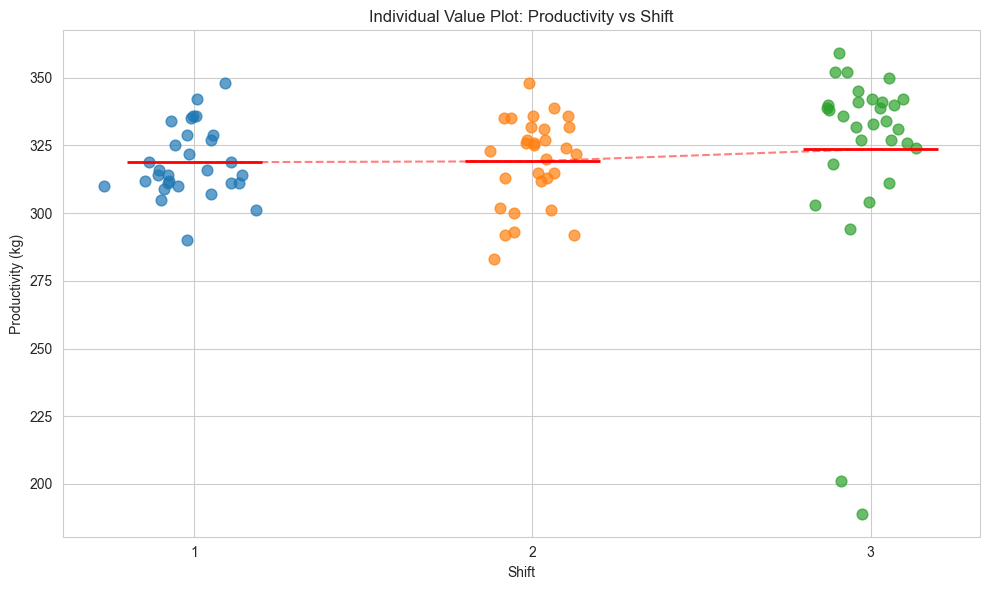

OBSERVATIONS:
  - The means are somewhat the same (line is more or less horizontal)
  - There are two outliers in Shift 3


In [3]:
# Individual Value Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Get data for each shift
shift_1 = productivity[productivity['Shift'] == '1']['Productivity'].values
shift_2 = productivity[productivity['Shift'] == '2']['Productivity'].values
shift_3 = productivity[productivity['Shift'] == '3']['Productivity'].values

# Plot individual values
for i, (shift_data, shift_name) in enumerate([(shift_1, '1'), (shift_2, '2'), (shift_3, '3')]):
    x = np.random.normal(i, 0.08, size=len(shift_data))
    ax.scatter(x, shift_data, alpha=0.7, s=60)
    # Add mean line
    mean = shift_data.mean()
    ax.hlines(mean, i-0.2, i+0.2, colors='red', linewidths=2)

# Connect means with line
means = [shift_1.mean(), shift_2.mean(), shift_3.mean()]
ax.plot([0, 1, 2], means, 'r--', alpha=0.5)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1', '2', '3'])
ax.set_xlabel('Shift')
ax.set_ylabel('Productivity (kg)')
ax.set_title('Individual Value Plot: Productivity vs Shift')

plt.tight_layout()
plt.show()

print('OBSERVATIONS:')
print('  - The means are somewhat the same (line is more or less horizontal)')
print('  - There are two outliers in Shift 3')

In [4]:
# ANOVA output
print('ANOVA OUTPUT')
print('=' * 60)
print()
print('Mean Productivity per Shift:')
print('-' * 40)
for shift in ['1', '2', '3']:
    data = productivity[productivity['Shift'] == shift]['Productivity']
    print(f'  Shift {shift}: Mean = {data.mean():.0f}')
print()

# Perform Welch's ANOVA (does not assume equal variances)
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(shift_1, shift_2, shift_3)

print('ANOVA Test:')
print('-' * 40)
print(f'  F-statistic: {f_stat:.3f}')
print(f'  P-value: {p_value:.3f}')
print()
print('Is this small difference statistically significant?')
print(f'P-value = {p_value:.3f}')
print()
print('There is NOT enough evidence for a difference in productivity')
print('due to the shift.')
print()
print('However, we first need to perform Step 3:')
print('Check the residuals before we know whether this conclusion is valid.')

ANOVA OUTPUT

Mean Productivity per Shift:
----------------------------------------
  Shift 1: Mean = 319
  Shift 2: Mean = 319
  Shift 3: Mean = 324

ANOVA Test:
----------------------------------------
  F-statistic: 0.351
  P-value: 0.705

Is this small difference statistically significant?
P-value = 0.705

There is NOT enough evidence for a difference in productivity
due to the shift.

However, we first need to perform Step 3:
Check the residuals before we know whether this conclusion is valid.


---

### Step 3: Check the Residuals

We need to check the residuals to know whether the ANOVA conclusion is valid.

In Minitab, we asked for the "Four in one" residual plot.

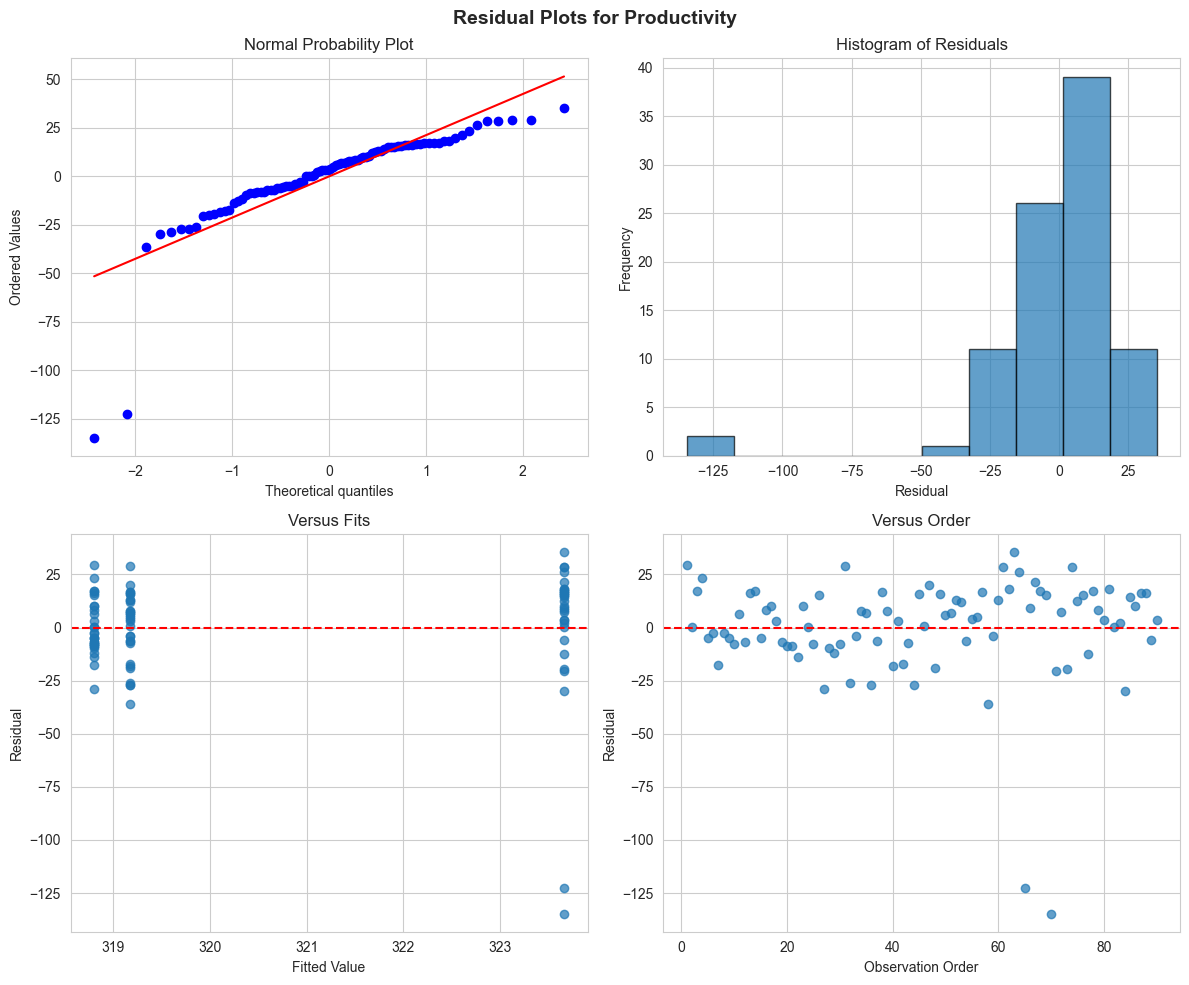

RESIDUAL ANALYSIS

In the four-in-one plots, we clearly see TWO OUTLIERS:
  - Both in the probability plot
  - And in the versus order plot

Hence, the ANOVA assumptions are NOT satisfied.


In [5]:
# Calculate residuals
group_means = productivity.groupby('Shift')['Productivity'].transform('mean')
productivity['Residual'] = productivity['Productivity'] - group_means
productivity['Fitted'] = group_means
productivity['Order'] = range(1, len(productivity) + 1)

# Four-in-one residual plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal probability plot
residuals = productivity['Residual'].values
stats.probplot(residuals, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram
axes[0, 1].hist(residuals, bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Versus Fits
axes[1, 0].scatter(productivity['Fitted'], residuals, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Versus Order
axes[1, 1].scatter(productivity['Order'], residuals, alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for Productivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('RESIDUAL ANALYSIS')
print('=' * 60)
print()
print('In the four-in-one plots, we clearly see TWO OUTLIERS:')
print('  - Both in the probability plot')
print('  - And in the versus order plot')
print()
print('Hence, the ANOVA assumptions are NOT satisfied.')

---

## Alternative: Kruskal-Wallis Analysis

Since the ANOVA assumptions are not satisfied, we have two options:

1. **Perform a Kruskal-Wallis analysis** (non-parametric alternative)
2. **Investigate the outliers** - If they are due to errors or not representative of the process, you can remove them and redo ANOVA (but always report that you removed/adjusted data)

Let's perform the Kruskal-Wallis analysis.

In Minitab: **Stat > Nonparametrics > Kruskal-Wallis**
- Response: Productivity
- Factor: Shift

In [6]:
# Kruskal-Wallis analysis
stat_kw, p_value_kw = stats.kruskal(shift_1, shift_2, shift_3)

print('KRUSKAL-WALLIS ANALYSIS')
print('=' * 60)
print()
print('Median Productivity per Shift:')
print('-' * 40)
for shift in ['1', '2', '3']:
    data = productivity[productivity['Shift'] == shift]['Productivity']
    print(f'  Shift {shift}: Median = {data.median():.0f}')
print()
print('Test Results:')
print('-' * 40)
print(f'  H-statistic: {stat_kw:.3f}')
print(f'  P-value: {p_value_kw:.3f}')

KRUSKAL-WALLIS ANALYSIS

Median Productivity per Shift:
----------------------------------------
  Shift 1: Median = 315
  Shift 2: Median = 324
  Shift 3: Median = 335

Test Results:
----------------------------------------
  H-statistic: 10.648
  P-value: 0.005


In [7]:
# Interpret the Kruskal-Wallis result
print('INTERPRETATION')
print('=' * 60)
print()
print('The Kruskal-Wallis analysis gives a DIFFERENT conclusion than ANOVA!')
print()
print(f'P-value = {p_value_kw:.3f}')
print()
if p_value_kw < 0.05:
    print('The p-value is lower than 0.05.')
    print()
    print('Meaning: Productivity DIFFERS across the shifts.')
    print()
    # Find shift with highest median
    medians = {}
    for shift in ['1', '2', '3']:
        medians[shift] = productivity[productivity['Shift'] == shift]['Productivity'].median()
    best_shift = max(medians, key=medians.get)
    print(f'How large is this difference?')
    print(f'  Shift {best_shift} has the highest median performance: {medians[best_shift]:.0f}')
else:
    print('P-value >= 0.05: No significant difference found.')

INTERPRETATION

The Kruskal-Wallis analysis gives a DIFFERENT conclusion than ANOVA!

P-value = 0.005

The p-value is lower than 0.05.

Meaning: Productivity DIFFERS across the shifts.

How large is this difference?
  Shift 3 has the highest median performance: 335


---

## Summary

1. **We found two outliers in our residuals**
   - Hence, the ANOVA assumptions are not satisfied

2. **We performed a Kruskal-Wallis analysis**
   - The Kruskal-Wallis analysis gave us a small p-value
   - We found statistical evidence that there is a significant difference between the productivity of the three shifts

3. **The third shift had the highest median productivity**
   - Therefore, the third shift was the most productive shift

### Practical Recommendation

A practitioner should now investigate **why** the third shift was performing better, and try to use its best practices in the first two shifts as well.